<a href="https://colab.research.google.com/github/simaryadav/learning_roadmap/blob/main/Fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pandas_datareader as pdr
from datetime import datetime
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('AIML Dataset.csv')

#About Dataset

The dataset contains the records of financial transactions for fraud detection. (6.3 Million Records)
Some of these records were flagged false by existing algorithms.

Further approaches could be used to feature engineer properties that could further strengthen the fraud detection algorithms as well as find out where the existing algorithm lacks.

CASH-IN: is the process of increasing the balance of
account by paying in cash to a merchant.

CASH-OUT: is the opposite process of CASH-IN, it
means to withdraw cash from a merchant which decreases
the balance of the account.

DEBIT: is similar process than CASH-OUT and involves sending the money from the mobile money service
to a bank account.

PAYMENT: is the process of paying for goods or services to merchants which decreases the balance of the account and increases the balance of the receiver.

TRANSFER: is the process of sending money to another user of the service through the mobile money platform

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## STEP-1 Performing EDA and Pre-Processing

In [4]:
df.sample(20)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2555027,206,CASH_IN,152096.63,C1601622135,2608428.15,2760524.77,C1562585051,610821.97,458725.34,0,0
4547507,326,CASH_IN,135274.69,C206015441,9190309.58,9325584.27,C1615456809,1643667.85,1508393.17,0,0
3900677,284,TRANSFER,368599.36,C181271547,20898.00,0.00,C20158042,60786.85,712698.89,0,0
3248094,250,TRANSFER,374119.54,C620515919,26353.00,0.00,C506581729,8194586.66,8568706.20,0,0
322545,16,CASH_IN,61127.21,C546350465,26037.00,87164.21,C1453795463,2245058.15,2845176.16,0,0
4205536,305,CASH_OUT,248849.64,C1927119153,536582.00,287732.36,C906879106,118164.20,367013.84,0,0
2468457,204,CASH_OUT,475525.14,C1039251894,11564.00,0.00,C49826420,36781.07,512306.21,0,0
4182827,304,PAYMENT,26194.79,C783054233,154961.22,128766.44,M827747143,0.00,0.00,0,0
2219456,186,CASH_OUT,232.02,C295733930,0.00,0.00,C1611953324,503116.20,503348.22,0,0
3848584,282,CASH_IN,142772.27,C1008772534,10023054.58,10165826.84,C1088049632,715070.76,572298.49,0,0


In [5]:
df.shape

(6362620, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
df.describe(include="all")


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C1530544995,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


In [9]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


The data is highly skewed, so we can apply SMOTE or consider alternative resampling and modeling techniques to address the imbalance.


In [10]:
df["isFraud"].value_counts()

,count
isFraud,
0,6354407
1,8213


<Axes: title={'center': 'Transaction counts by types'}, xlabel='type'>

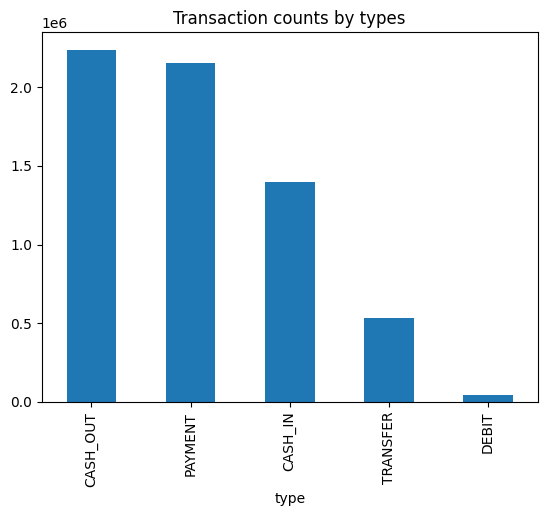

In [11]:
df["type"].value_counts().plot(kind="bar",title="Transaction counts by types")

There are two main types of fraud in the dataset. While we could focus primarily on these categories, I plan to use the entire dataset to obtain the most comprehensive results.


In [12]:
frauds_by_type = df.groupby("type")["isFraud"].sum()
frauds_by_type

,isFraud
type,
CASH_IN,0
CASH_OUT,4116
DEBIT,0
PAYMENT,0
TRANSFER,4097


<Axes: title={'center': 'Various fraud counts'}, xlabel='type'>

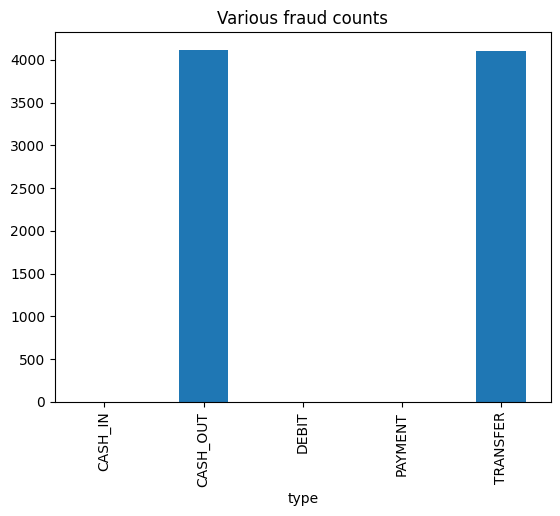

In [54]:
frauds_by_type.plot(kind="bar", title = "Various fraud counts")

In [14]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

Now we create two features that capture the difference between the old and new balances for both the origin and destination accounts.

In [15]:
df["balancediffdest"] = df["oldbalanceDest"] - df["newbalanceDest"]
df["balancedifforg"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

In [16]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediffdest,balancedifforg
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,181.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,21182.0,181.00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,11668.14


In [17]:
df["step"].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

In [18]:
df.drop(columns = "step" , inplace = True)

In [19]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediffdest,balancedifforg
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,181.00
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,21182.0,181.00
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,11668.14


In [20]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

,count
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
C1462946854,3
C1065307291,3
C1999539787,3
C2098525306,3


Now we examine the different types of fraudsters involved in these transactions as a precautionary step.


In [21]:
frauds = df[df["isFraud"] == 1]["nameOrig"].value_counts()

In [22]:
frauds

,count
nameOrig,
C1280323807,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
...,...
C1364127192,1
C467632528,1
C1334405552,1


In [23]:
fraud_df = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [24]:
fraud_df

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediffdest,balancedifforg
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,0.00,181.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,21182.00,181.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,-46430.44,15325.00
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,22425.00,705.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,-2712905.89,10835.00
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,-339682.13,339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,0.00,6311409.28
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,-6311409.27,6311409.28
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,0.00,850002.52


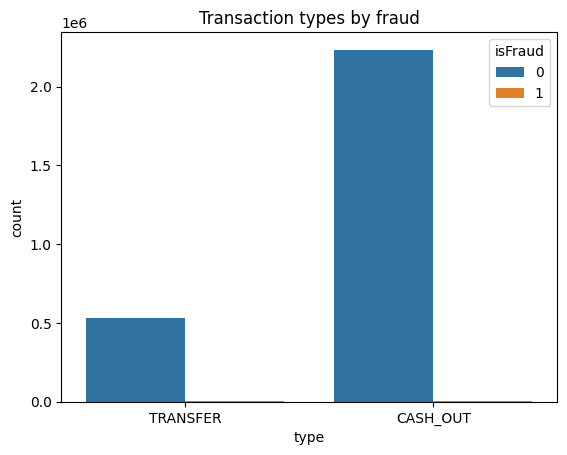

In [25]:
sns.countplot(data=fraud_df,x="type",hue = "isFraud")
plt.title("Transaction types by fraud")
plt.show()

Now we plot a correlation heatmap of the existing numerical features to better understand the relationships between them.


In [26]:
corr_df = df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()

In [27]:
corr_df

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


<Axes: >

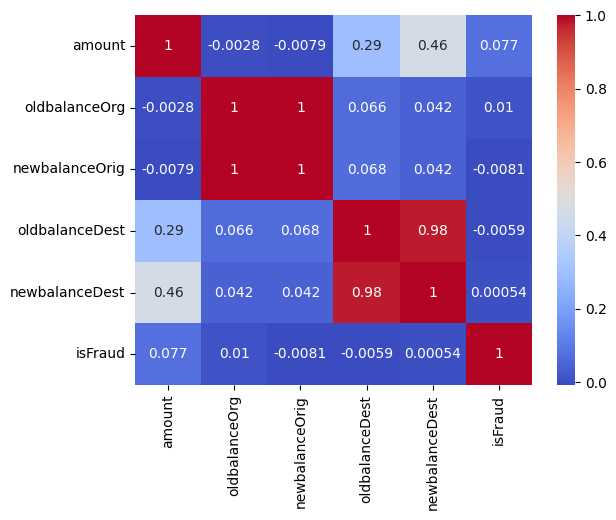

In [28]:
sns.heatmap(corr_df,annot = True,cmap="coolwarm")

We observe that oldbalanceDest and newbalanceDest has high correlation with isFraud

In [29]:
zero_balance = df[(df["oldbalanceOrg"] > 0) & (df["newbalanceOrig"] == 0) & (df["type"].isin(["TRANSFER","CASH_OUT"]))]

In [30]:
zero_balance

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediffdest,balancedifforg
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,0.00,181.00
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,21182.00,181.00
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,-46430.44,15325.00
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,22425.00,705.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,-2712905.89,10835.00
...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,-339682.13,339682.13
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,0.00,6311409.28
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,-6311409.27,6311409.28
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,0.00,850002.52


In nearly all fraudulent transfers, the account’s new balance drops to 0, revealing a consistent behavioral pattern.

In [31]:
zero_balance["isFraud"].value_counts()

,count
isFraud,
0,1180062
1,8012


## STEP-2 MODEL TRAINING AND PERFORMANCE REVIEW

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
import xgboost as xgb

In [33]:
df_model = df.drop(columns = ["nameOrig","nameDest","isFlaggedFraud"])

In [34]:
df_model

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balancediffdest,balancedifforg
0,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0.00,9839.64
1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0.00,1864.28
2,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0.00,181.00
3,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,21182.00,181.00
4,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0.00,11668.14
...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,-339682.13,339682.13
6362616,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0.00,6311409.28
6362617,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,-6311409.27,6311409.28
6362618,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0.00,850002.52


We split the data into two subsets, using a binary target variable
y that indicates whether a transaction is fraudulent or not.


In [35]:
y = df_model["isFraud"]
x = df_model.drop(columns = "isFraud")

In [36]:
categorical = ["type"]
numerical = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

Now we perform One Hot Encoding on the categorical variables

In [37]:
X_cat = pd.get_dummies(
    x[categorical],
    drop_first=False
)

In [38]:
X_cat

,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,False,False,False,True,False
1,False,False,False,True,False
2,False,False,False,False,True
3,False,True,False,False,False
4,False,False,False,True,False
...,...,...,...,...,...
6362615,False,True,False,False,False
6362616,False,False,False,False,True
6362617,False,True,False,False,False
6362618,False,False,False,False,True


We also apply a StandardScaler to the numeric features, since scaling helps logistic regression train more effectively and ensures all features contribute on a comparable scale.


In [39]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(x[numerical])

In [40]:
X_num_scaled

array([[-2.81559923e-01, -2.29810037e-01, -2.37621696e-01,
        -3.23813895e-01, -3.33411405e-01],
       [-2.94767262e-01, -2.81359380e-01, -2.85812295e-01,
        -3.23813895e-01, -3.33411405e-01],
       [-2.97554804e-01, -2.88653782e-01, -2.92441707e-01,
        -3.23813895e-01, -3.33411405e-01],
       ...,
       [ 1.01539526e+01,  1.89649113e+00, -2.92441707e-01,
        -3.03665258e-01,  1.40302700e+00],
       [ 1.10976490e+00,  5.58104668e-03, -2.92441707e-01,
        -3.23813895e-01, -3.33411405e-01],
       [ 1.10976490e+00,  5.58104668e-03, -2.92441707e-01,
         1.59138312e+00,  1.66981230e+00]])

In [42]:
X_num_scaled = pd.DataFrame(
    X_num_scaled,
    columns=numerical,
    index=x.index
)

In [43]:
X_num_scaled

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,-0.281560,-0.229810,-0.237622,-0.323814,-0.333411
1,-0.294767,-0.281359,-0.285812,-0.323814,-0.333411
2,-0.297555,-0.288654,-0.292442,-0.323814,-0.333411
3,-0.297555,-0.288654,-0.292442,-0.317582,-0.333411
4,-0.278532,-0.274329,-0.282221,-0.323814,-0.333411
...,...,...,...,...,...
6362615,0.264665,-0.171108,-0.292442,-0.323814,-0.240959
6362616,10.153953,1.896491,-0.292442,-0.323814,-0.333411
6362617,10.153953,1.896491,-0.292442,-0.303665,1.403027
6362618,1.109765,0.005581,-0.292442,-0.323814,-0.333411


In [44]:
X_processed = pd.concat([X_num_scaled, X_cat], axis=1)

In [45]:
X_train,X_test,Y_train,Y_test = train_test_split(X_processed,y,test_size = 0.3,stratify = y,random_state = 42)

In [46]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

log_reg.fit(X_train, Y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1)

In [48]:
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

In [50]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(Y_train == 0).sum() / (Y_train == 1).sum(),
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [51]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [53]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "Accuracy": [
        accuracy_score(Y_test, y_pred_lr),
        accuracy_score(Y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(Y_test, y_pred_lr),
        precision_score(Y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(Y_test, y_pred_lr),
        recall_score(Y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(Y_test, y_pred_lr),
        f1_score(Y_test, y_pred_xgb)
    ],
    "ROC AUC": [
        roc_auc_score(Y_test, y_prob_lr),
        roc_auc_score(Y_test, y_prob_xgb)
    ]
})

results


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.946788,0.022298,0.938718,0.043561,0.989122
1,XGBoost,0.994659,0.194031,0.994724,0.324722,0.999565


XGBoost clearly outperforms logistic regression on this highly skewed bank fraud dataset. It achieves much higher precision (0.19 vs 0.02), F1 score (0.32 vs 0.04), and a slightly better ROC AUC (0.9996 vs 0.9891), while also maintaining higher overall accuracy and recall. Logistic regression detects most frauds (high recall) but with very low precision, meaning it produces many false positives, whereas XGBoost provides a much better balance between detecting fraud and limiting false alarms.